<a href="https://colab.research.google.com/github/Ravi-ranjan1801/CUDA-Lab/blob/main/Lab_05_Thread_variation%26shared_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
%%writefile matmul_thread_variation.cu

 // matmul_thread_variation.cu
#include <stdio.h>
#include <cuda.h>
#include <stdlib.h>

#define N 256   // fixed matrix size

__global__ void matMul(int *A,int *B,int *C,int n)
{
    int row = blockIdx.y * blockDim.x + threadIdx.x;
    int col = blockIdx.x;

    if(row < n && col < n)
    {
        int sum = 0;
        for(int k=0;k<n;k++)
            sum += A[row*n+k] * B[k*n+col];

        C[row*n+col] = sum;
    }
}

int main()
{
    int threads_list[] = {3,5,7,32,64,128};
    int tests = 6;

    int size = N*N*sizeof(int);

    int *A=(int*)malloc(size);
    int *B=(int*)malloc(size);
    int *C=(int*)malloc(size);

    for(int i=0;i<N*N;i++)
    {
        A[i]=5;
        B[i]=7;
    }

    int *dA,*dB,*dC;

    cudaMalloc(&dA,size);
    cudaMalloc(&dB,size);
    cudaMalloc(&dC,size);

    cudaMemcpy(dA,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,size,cudaMemcpyHostToDevice);

    FILE *f = fopen("matmul_threads_variation.csv","w");
    fprintf(f,"Threads,GPU_Time\n");

    for(int t=0;t<tests;t++)
    {
        int threads = threads_list[t];

        dim3 block(threads,1);
        dim3 grid(N, (N+threads-1)/threads);

        cudaEvent_t s,e;
        cudaEventCreate(&s);
        cudaEventCreate(&e);

        cudaEventRecord(s);

        matMul<<<grid,block>>>(dA,dB,dC,N);

        cudaEventRecord(e);
        cudaEventSynchronize(e);

        float ms;
        cudaEventElapsedTime(&ms,s,e);

        printf("Threads=%d Time=%f ms\n",threads,ms);

        fprintf(f,"%d,%f\n",threads,ms);

        cudaEventDestroy(s);
        cudaEventDestroy(e);
    }

    fclose(f);

    cudaFree(dA);
    cudaFree(dB);
    cudaFree(dC);

    free(A);
    free(B);
    free(C);

    printf("\nCSV generated\n");
}

Overwriting matmul_thread_variation.cu


In [24]:
!nvcc matmul_thread_variation.cu -o matmul_thread_test
!./matmul_thread_test

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Threads=3 Time=1.764800 ms
Threads=5 Time=1.443328 ms
Threads=7 Time=1.368672 ms
Threads=32 Time=1.236128 ms
Threads=64 Time=1.236992 ms
Threads=128 Time=1.238496 ms

CSV generated


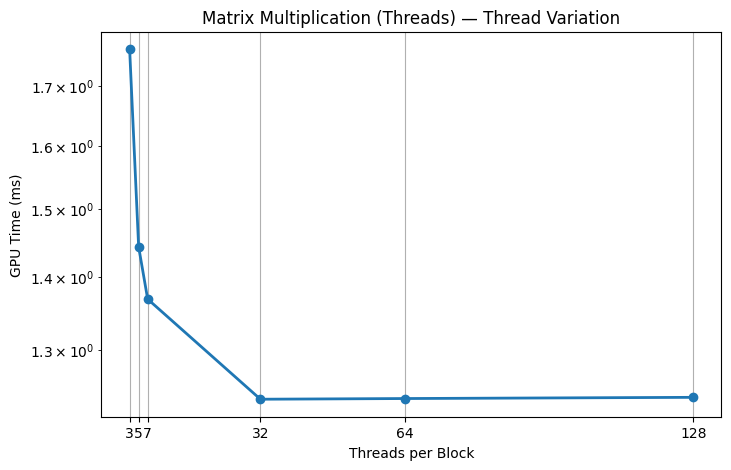

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("matmul_threads_variation.csv")

plt.figure(figsize=(8,5))

plt.plot(data.Threads,
         data.GPU_Time,
         marker='o',
         linewidth=2)

plt.yscale("log")

plt.xlabel("Threads per Block")
plt.ylabel("GPU Time (ms)")
plt.title("Matrix Multiplication (Threads) — Thread Variation")
plt.grid(True)
plt.xticks(data.Threads)

plt.show()

In [29]:
%%writefile matmul_shared_variation.cu
// matmul_shared_variation.cu
#include <stdio.h>
#include <cuda.h>
#include <stdlib.h>

#define N 256
#define TILE 16

__global__ void matMulShared(int *A,int *B,int *C,int n)
{
    __shared__ int sA[TILE][TILE];
    __shared__ int sB[TILE][TILE];

    int row = blockIdx.y*TILE + threadIdx.y;
    int col = blockIdx.x*TILE + threadIdx.x;

    int sum = 0;

    for(int t=0;t<n/TILE;t++)
    {
        sA[threadIdx.y][threadIdx.x] =
            A[row*n + t*TILE + threadIdx.x];

        sB[threadIdx.y][threadIdx.x] =
            B[(t*TILE + threadIdx.y)*n + col];

        __syncthreads();

        for(int k=0;k<TILE;k++)
            sum += sA[threadIdx.y][k]*sB[k][threadIdx.x];

        __syncthreads();
    }

    C[row*n+col] = sum;
}

int main()
{
    int threads_list[] = {3,5,7,32,64,128};
    int tests = 6;

    int size = N*N*sizeof(int);

    int *A=(int*)malloc(size);
    int *B=(int*)malloc(size);
    int *C=(int*)malloc(size);

    for(int i=0;i<N*N;i++)
    {
        A[i]=5;
        B[i]=7;
    }

    int *dA,*dB,*dC;

    cudaMalloc(&dA,size);
    cudaMalloc(&dB,size);
    cudaMalloc(&dC,size);

    cudaMemcpy(dA,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,size,cudaMemcpyHostToDevice);

    FILE *f = fopen("matmul_shared_variation.csv","w");
    fprintf(f,"Threads,GPU_Time\n");

    for(int t=0;t<tests;t++)
    {
        int threads = threads_list[t];

        dim3 block(16,16);
        dim3 grid(N/16,N/16);

        cudaEvent_t s,e;
        cudaEventCreate(&s);
        cudaEventCreate(&e);

        cudaEventRecord(s);

        matMulShared<<<grid,block>>>(dA,dB,dC,N);

        cudaEventRecord(e);
        cudaEventSynchronize(e);

        float ms;
        cudaEventElapsedTime(&ms,s,e);

        printf("Threads=%d Time=%f ms\n",threads,ms);

        fprintf(f,"%d,%f\n",threads,ms);

        cudaEventDestroy(s);
        cudaEventDestroy(e);
    }

    fclose(f);

    cudaFree(dA);
    cudaFree(dB);
    cudaFree(dC);

    free(A);
    free(B);
    free(C);

    printf("\nCSV generated\n");
}

Overwriting matmul_shared_variation.cu


In [30]:
!nvcc matmul_shared_variation.cu -o matmul_shared_test
!./matmul_shared_test

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Threads=3 Time=0.349376 ms
Threads=5 Time=0.096256 ms
Threads=7 Time=0.094304 ms
Threads=32 Time=0.092128 ms
Threads=64 Time=0.093024 ms
Threads=128 Time=0.092192 ms

CSV generated


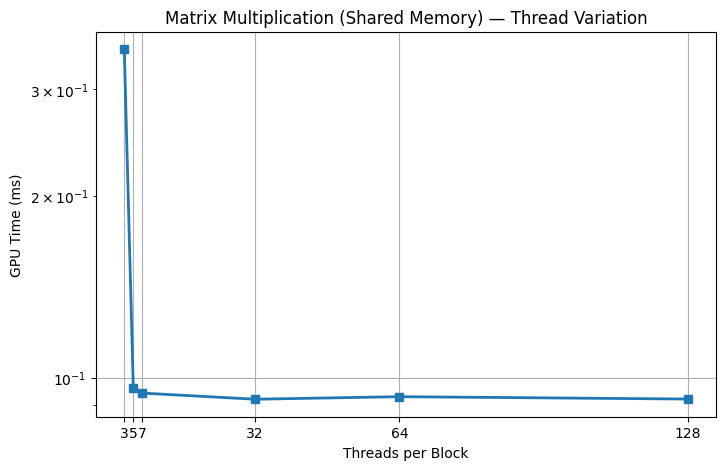

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("matmul_shared_variation.csv")

plt.figure(figsize=(8,5))

plt.plot(data.Threads,
         data.GPU_Time,
         marker='s',
         linewidth=2)

plt.yscale("log")

plt.xlabel("Threads per Block")
plt.ylabel("GPU Time (ms)")
plt.title("Matrix Multiplication (Shared Memory) — Thread Variation")
plt.grid(True)
plt.xticks(data.Threads)

plt.show()